# Exploracao dos Dados BCB

Notebook para verificar integridade dos dados coletados do Banco Central do Brasil.

**Dados disponiveis:**
- **SGS Daily**: Selic, CDI, Dolar PTAX, Euro PTAX
- **SGS Monthly**: IBC-Br Bruto, IBC-Br Dessazonalizado, IGP-M
- **Expectations**: Expectativas do Relatorio Focus (IPCA, IGP-M, PIB, Cambio, Selic)

## 1. Setup e Carregamento

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Configurar matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10

# Caminho para dados
data_path = Path.cwd().parent / 'data'
processed_path = data_path / 'processed'

print(f"Data path: {data_path}")

Data path: c:\Users\Enzo\Documents\Programming\dados-bcb\data


In [20]:
# Carregar todos os dados consolidados
df_sgs_daily = pd.read_parquet(processed_path / 'sgs_daily_consolidated.parquet')
df_sgs_monthly = pd.read_parquet(processed_path / 'sgs_monthly_consolidated.parquet')
df_expectations = pd.read_parquet(processed_path / 'expectations_consolidated.parquet')

print("Dados carregados com sucesso!")
print(f"  SGS Daily: {df_sgs_daily.shape[0]:,} registros x {df_sgs_daily.shape[1]} colunas")
print(f"  SGS Monthly: {df_sgs_monthly.shape[0]:,} registros x {df_sgs_monthly.shape[1]} colunas")
print(f"  Expectations: {df_expectations.shape[0]:,} registros x {df_expectations.shape[1]} colunas")

Dados carregados com sucesso!
  SGS Daily: 13,337 registros x 4 colunas
  SGS Monthly: 437 registros x 3 colunas
  Expectations: 669,102 registros x 13 colunas


## 2. SGS Daily

In [21]:
print("=" * 60)
print("SGS DAILY")
print("=" * 60)
print(f"\nShape: {df_sgs_daily.shape}")
print(f"Colunas: {list(df_sgs_daily.columns)}")
print(f"Periodo: {df_sgs_daily.index.min()} a {df_sgs_daily.index.max()}")
print(f"\nValores faltantes:")
print(df_sgs_daily.isna().sum())

SGS DAILY

Shape: (13337, 4)
Colunas: ['cdi', 'dolar_ptax', 'euro_ptax', 'selic']
Periodo: 1984-11-28 00:00:00 a 2025-12-10 00:00:00

Valores faltantes:
cdi           3391
dolar_ptax    3057
euro_ptax     6577
selic         3559
dtype: int64


In [22]:
print("Primeiros registros:")
display(df_sgs_daily.head())
print("\nUltimos registros:")
display(df_sgs_daily.tail())

Primeiros registros:


,cdi,dolar_ptax,euro_ptax,selic
Date,,,,
1984-11-28,NaN,2814.0,NaN,NaN
1984-11-29,NaN,2814.0,NaN,NaN
1984-11-30,NaN,2867.0,NaN,NaN
1984-12-03,NaN,2867.0,NaN,NaN
1984-12-04,NaN,2867.0,NaN,NaN



Ultimos registros:


,cdi,dolar_ptax,euro_ptax,selic
Date,,,,
2025-12-06,NaN,NaN,NaN,15.0
2025-12-07,NaN,NaN,NaN,15.0
2025-12-08,NaN,NaN,NaN,15.0
2025-12-09,NaN,NaN,NaN,15.0
2025-12-10,NaN,NaN,NaN,15.0


## 3. SGS Monthly

In [23]:
print("=" * 60)
print("SGS MONTHLY")
print("=" * 60)
print(f"\nShape: {df_sgs_monthly.shape}")
print(f"Colunas: {list(df_sgs_monthly.columns)}")
print(f"Periodo: {df_sgs_monthly.index.min()} a {df_sgs_monthly.index.max()}")
print(f"\nValores faltantes:")
print(df_sgs_monthly.isna().sum())

SGS MONTHLY

Shape: (437, 3)
Colunas: ['ibc_br_bruto', 'ibc_br_dessaz', 'igp_m']
Periodo: 1989-07-01 00:00:00 a 2025-11-01 00:00:00

Valores faltantes:
ibc_br_bruto     164
ibc_br_dessaz    164
igp_m              0
dtype: int64


In [24]:
print("Primeiros registros:")
display(df_sgs_monthly.head())
print("\nUltimos registros:")
display(df_sgs_monthly.tail())

Primeiros registros:


,ibc_br_bruto,ibc_br_dessaz,igp_m
Date,,,
1989-07-01,NaN,NaN,35.90
1989-08-01,NaN,NaN,36.92
1989-09-01,NaN,NaN,39.92
1989-10-01,NaN,NaN,40.64
1989-11-01,NaN,NaN,40.48



Ultimos registros:


,ibc_br_bruto,ibc_br_dessaz,igp_m
Date,,,
2025-07-01,113.06029,108.20909,-0.77
2025-08-01,110.37876,108.63616,0.36
2025-09-01,109.24425,108.37301,0.42
2025-10-01,NaN,NaN,-0.36
2025-11-01,NaN,NaN,0.27


## 4. Expectations

In [25]:
print("=" * 60)
print("EXPECTATIONS")
print("=" * 60)
print(f"\nShape: {df_expectations.shape}")
print(f"Colunas: {list(df_expectations.columns)}")
print(f"Periodo: {df_expectations.index.min()} a {df_expectations.index.max()}")
print(f"\nValores faltantes:")
print(df_expectations.isna().sum())

EXPECTATIONS

Shape: (669102, 13)
Colunas: ['Indicador', 'Suavizada', 'Media', 'Mediana', 'DesvioPadrao', 'Minimo', 'Maximo', 'numeroRespondentes', 'baseCalculo', '_source', 'DataReferencia', 'tipoCalculo', 'Reuniao']
Periodo: 2000-01-03 00:00:00 a 2025-11-28 00:00:00

Valores faltantes:
Indicador                  0
Suavizada             631955
Media                    769
Mediana                  954
DesvioPadrao           88790
Minimo                 96230
Maximo                 96230
numeroRespondentes    384684
baseCalculo           253859
_source                    0
DataReferencia        119217
tipoCalculo           415243
Reuniao               587032
dtype: int64


In [26]:
# Contagem por fonte (_source)
print("Registros por indicador (_source):")
print(df_expectations['_source'].value_counts().sort_index())

Registros por indicador (_source):
_source
igpm_12m        14413
igpm_anual      77750
igpm_mensal    122194
ipca_12m        18038
ipca_24m         4696
ipca_anual      89906
ipca_mensal    173832
pib_anual        3630
selic           82070
selic_anual     82573
Name: count, dtype: int64


In [27]:
print("Primeiros registros:")
display(df_expectations.head())
print("\nUltimos registros:")
display(df_expectations.tail())

Primeiros registros:


,Indicador,Suavizada,Media,Mediana,DesvioPadrao,Minimo,Maximo,numeroRespondentes,baseCalculo,_source,DataReferencia,tipoCalculo,Reuniao
Date,,,,,,,,,,,,,
2000-01-03,IPCA,None,0.61,0.58,0.15,NaN,NaN,NaN,0.0,ipca_mensal,05/2000,None,None
2000-01-03,IPCA,None,0.60,0.60,0.19,NaN,NaN,NaN,0.0,ipca_mensal,04/2000,None,None
2000-01-04,IPCA,None,0.60,0.55,0.14,NaN,NaN,NaN,0.0,ipca_mensal,05/2000,None,None
2000-01-04,IPCA,None,0.60,0.60,0.19,NaN,NaN,NaN,0.0,ipca_mensal,04/2000,None,None
2000-01-05,IPCA,None,0.61,0.60,0.19,NaN,NaN,NaN,0.0,ipca_mensal,04/2000,None,None



Ultimos registros:


,Indicador,Suavizada,Media,Mediana,DesvioPadrao,Minimo,Maximo,numeroRespondentes,baseCalculo,_source,DataReferencia,tipoCalculo,Reuniao
Date,,,,,,,,,,,,,
2025-11-28,Selic,None,13.9459,14.0000,0.4345,12.2500,15.000,134.0,0.0,selic,None,None,R3/2026
2025-11-28,Selic,None,13.8654,14.0000,0.4832,12.2500,14.750,39.0,1.0,selic,None,None,R3/2026
2025-11-28,Selic,None,13.4683,13.5000,0.5151,11.7500,15.000,134.0,0.0,selic,None,None,R4/2026
2025-11-28,Selic,None,13.0056,13.0000,0.5710,11.0000,15.000,134.0,0.0,selic,None,None,R5/2026
2025-11-28,IGP-M,N,4.1573,4.1987,1.0552,1.8308,7.213,19.0,1.0,igpm_12m,None,None,None


## 5. Cobertura Temporal

In [28]:
def cobertura_temporal(df, nome):
    """Analisa a cobertura temporal de cada coluna."""
    print(f"\n{nome}")
    print("-" * 70)
    for col in df.columns:
        if col == '_source':
            continue
        dados = df[col].dropna()
        if len(dados) > 0:
            try:
                print(f"{col:30} | {dados.index.min().strftime('%Y-%m-%d')} a {dados.index.max().strftime('%Y-%m-%d')} | {len(dados):>8,} registros")
            except Exception:
                print(f"{col:30} | {len(dados):>8,} registros")
        else:
            print(f"{col:30} | SEM DADOS")

cobertura_temporal(df_sgs_daily, "SGS DAILY")
cobertura_temporal(df_sgs_monthly, "SGS MONTHLY")


SGS DAILY
----------------------------------------------------------------------
cdi                            | 1986-03-06 a 2025-12-03 |    9,946 registros
dolar_ptax                     | 1984-11-28 a 2025-12-04 |   10,280 registros
euro_ptax                      | 1998-12-31 a 2025-12-04 |    6,760 registros
selic                          | 1999-03-05 a 2025-12-10 |    9,778 registros

SGS MONTHLY
----------------------------------------------------------------------
ibc_br_bruto                   | 2003-01-01 a 2025-09-01 |      273 registros
ibc_br_dessaz                  | 2003-01-01 a 2025-09-01 |      273 registros
igp_m                          | 1989-07-01 a 2025-11-01 |      437 registros


In [29]:
# Cobertura temporal por fonte de expectations
# Agora o indice e DatetimeIndex, entao podemos usar diretamente
print("\nEXPECTATIONS (por _source)")
print("-" * 70)

for source in sorted(df_expectations['_source'].unique()):
    subset = df_expectations[df_expectations['_source'] == source]
    min_date = subset.index.min().strftime('%Y-%m-%d')
    max_date = subset.index.max().strftime('%Y-%m-%d')
    print(f"{source:30} | {min_date} a {max_date} | {len(subset):>8,} registros")


EXPECTATIONS (por _source)
----------------------------------------------------------------------
igpm_12m                       | 2001-11-07 a 2025-11-28 |   14,413 registros
igpm_anual                     | 2001-11-16 a 2025-11-28 |   77,750 registros
igpm_mensal                    | 2001-01-04 a 2025-11-28 |  122,194 registros
ipca_12m                       | 2001-11-07 a 2025-11-28 |   18,038 registros
ipca_24m                       | 2021-03-31 a 2025-11-28 |    4,696 registros
ipca_anual                     | 2001-11-06 a 2025-11-28 |   89,906 registros
ipca_mensal                    | 2000-01-03 a 2025-11-28 |  173,832 registros
pib_anual                      | 2023-03-31 a 2025-11-28 |    3,630 registros
selic                          | 2004-11-18 a 2025-11-28 |   82,070 registros
selic_anual                    | 2001-11-06 a 2025-11-28 |   82,573 registros


## 6. Visualizacoes - SGS

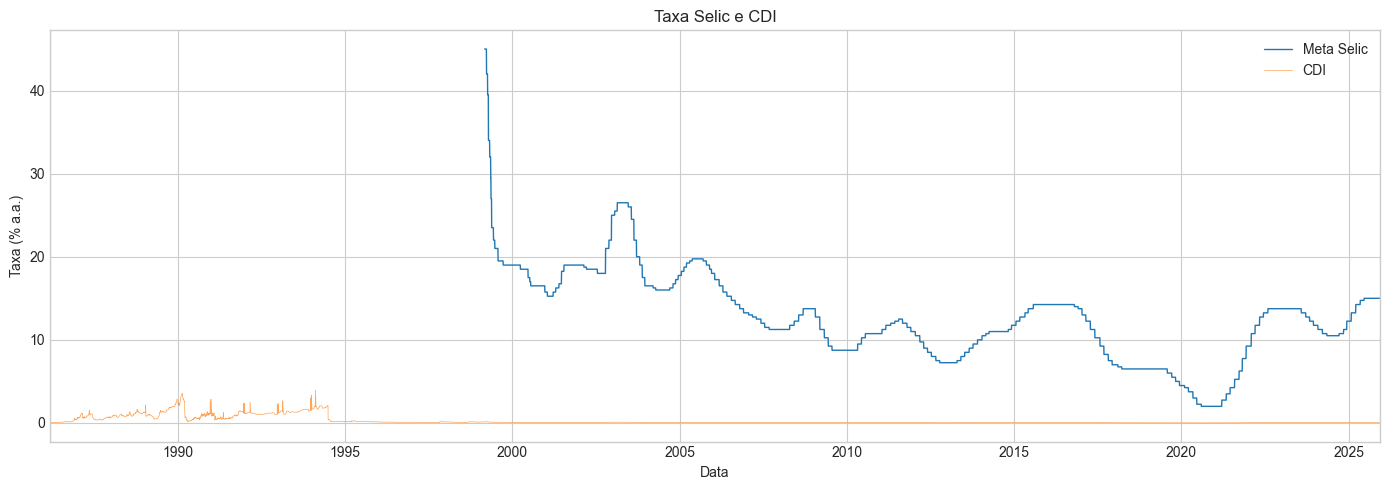

In [30]:
# Selic e CDI
fig, ax = plt.subplots(figsize=(14, 5))

if 'selic' in df_sgs_daily.columns:
    df_sgs_daily['selic'].dropna().plot(ax=ax, label='Meta Selic', linewidth=1)
if 'cdi' in df_sgs_daily.columns:
    df_sgs_daily['cdi'].dropna().plot(ax=ax, label='CDI', linewidth=0.5, alpha=0.7)

ax.set_title('Taxa Selic e CDI')
ax.set_xlabel('Data')
ax.set_ylabel('Taxa (% a.a.)')
ax.legend()
plt.tight_layout()
plt.show()

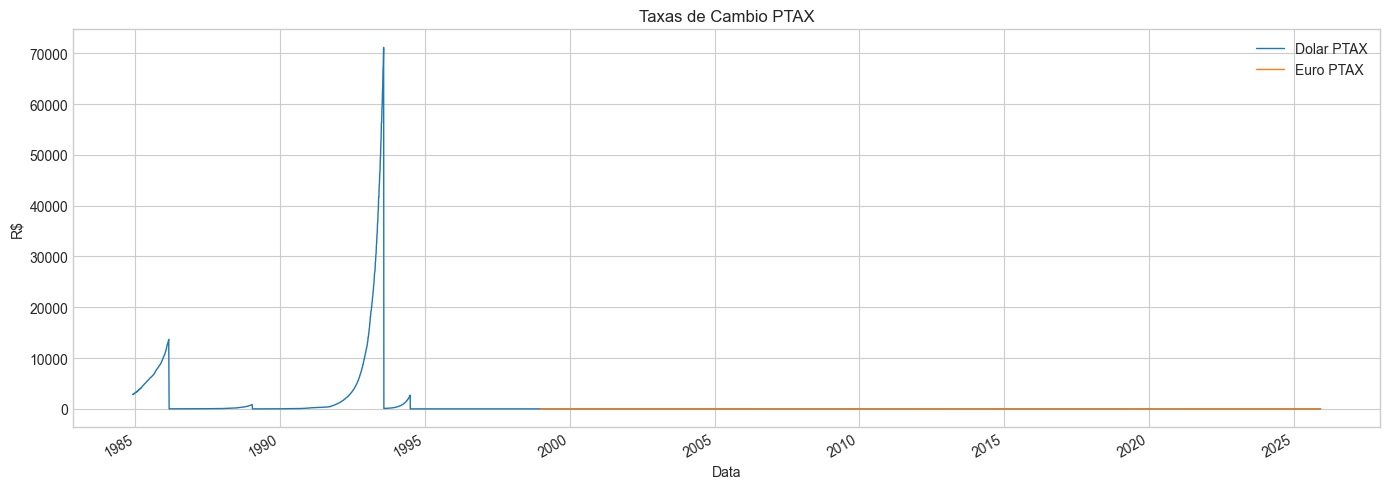

In [31]:
# Dolar e Euro PTAX
fig, ax = plt.subplots(figsize=(14, 5))

if 'dolar_ptax' in df_sgs_daily.columns:
    df_sgs_daily['dolar_ptax'].dropna().plot(ax=ax, label='Dolar PTAX', linewidth=1)
if 'euro_ptax' in df_sgs_daily.columns:
    df_sgs_daily['euro_ptax'].dropna().plot(ax=ax, label='Euro PTAX', linewidth=1)

ax.set_title('Taxas de Cambio PTAX')
ax.set_xlabel('Data')
ax.set_ylabel('R$')
ax.legend()
plt.tight_layout()
plt.show()

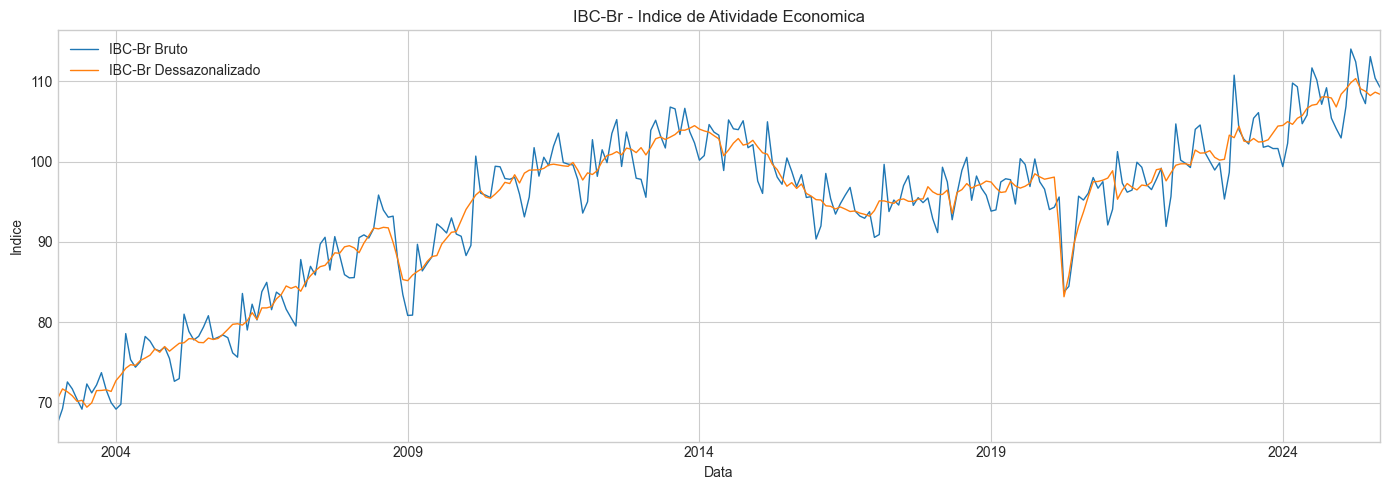

In [32]:
# IBC-Br
fig, ax = plt.subplots(figsize=(14, 5))

if 'ibc_br_bruto' in df_sgs_monthly.columns:
    df_sgs_monthly['ibc_br_bruto'].dropna().plot(ax=ax, label='IBC-Br Bruto', linewidth=1)
if 'ibc_br_dessaz' in df_sgs_monthly.columns:
    df_sgs_monthly['ibc_br_dessaz'].dropna().plot(ax=ax, label='IBC-Br Dessazonalizado', linewidth=1)

ax.set_title('IBC-Br - Indice de Atividade Economica')
ax.set_xlabel('Data')
ax.set_ylabel('Indice')
ax.legend()
plt.tight_layout()
plt.show()

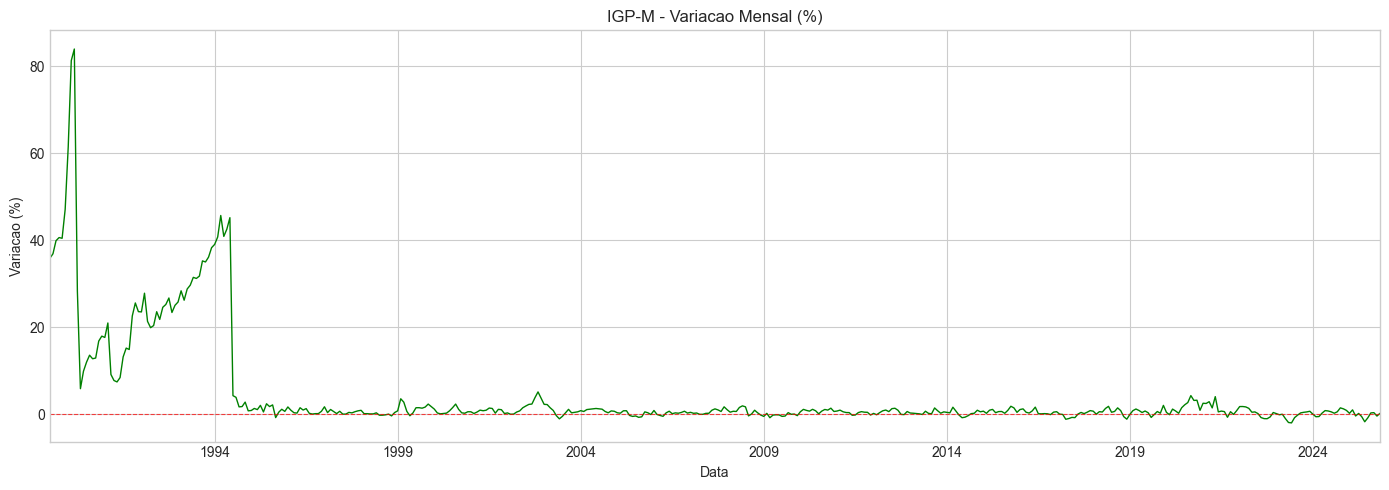

In [33]:
# IGP-M
fig, ax = plt.subplots(figsize=(14, 5))

if 'igp_m' in df_sgs_monthly.columns:
    df_sgs_monthly['igp_m'].dropna().plot(ax=ax, color='green', linewidth=1)

ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_title('IGP-M - Variacao Mensal (%)')
ax.set_xlabel('Data')
ax.set_ylabel('Variacao (%)')
plt.tight_layout()
plt.show()

## 7. Visualizacoes - Expectations

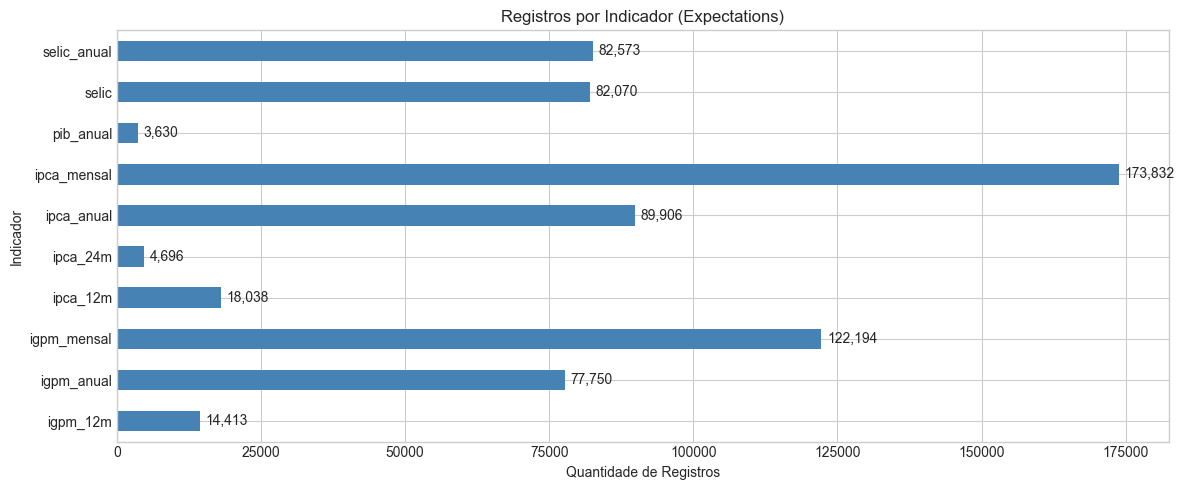

In [34]:
# Distribuicao de registros por fonte
fig, ax = plt.subplots(figsize=(12, 5))

counts = df_expectations['_source'].value_counts().sort_index()
counts.plot(kind='barh', ax=ax, color='steelblue')

ax.set_title('Registros por Indicador (Expectations)')
ax.set_xlabel('Quantidade de Registros')
ax.set_ylabel('Indicador')

# Adicionar valores nas barras
for i, v in enumerate(counts.values):
    ax.text(v + 1000, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

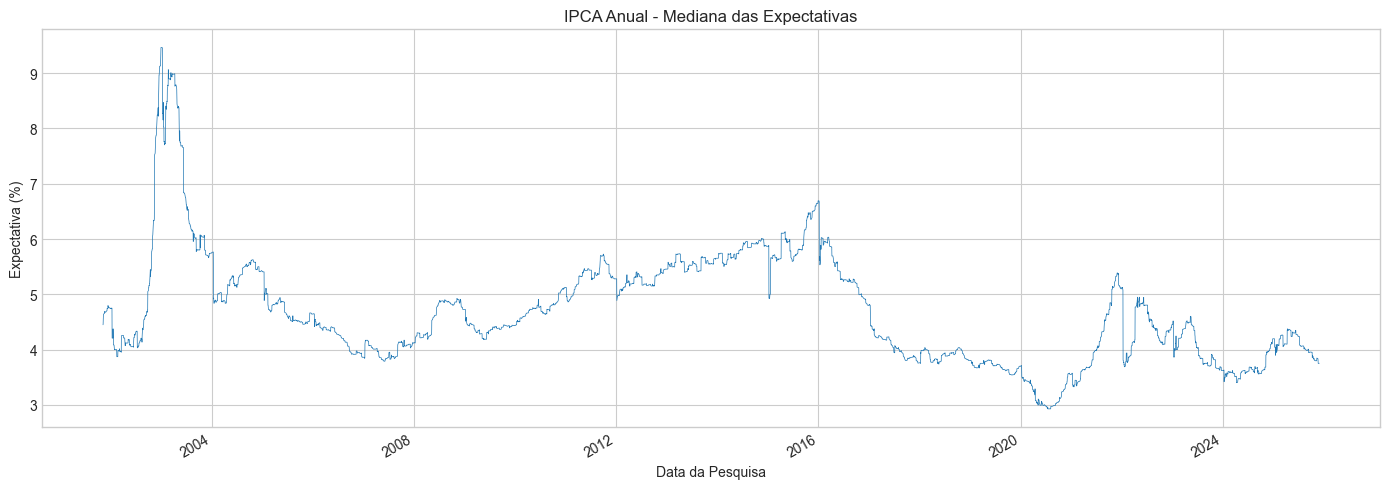

Periodo: 2001-11-06 00:00:00 a 2025-11-28 00:00:00
Registros: 89,906


In [35]:
# Exemplo: IPCA Anual - Mediana ao longo do tempo
if 'ipca_anual' in df_expectations['_source'].values:
    ipca_anual = df_expectations[df_expectations['_source'] == 'ipca_anual'].copy()
    
    # Agrupar por data e calcular media da mediana
    if 'Mediana' in ipca_anual.columns:
        mediana_diaria = ipca_anual.groupby(ipca_anual.index)['Mediana'].mean()
        
        fig, ax = plt.subplots(figsize=(14, 5))
        mediana_diaria.plot(ax=ax, linewidth=0.5)
        
        ax.set_title('IPCA Anual - Mediana das Expectativas')
        ax.set_xlabel('Data da Pesquisa')
        ax.set_ylabel('Expectativa (%)')
        plt.tight_layout()
        plt.show()
        
        print(f"Periodo: {ipca_anual.index.min()} a {ipca_anual.index.max()}")
        print(f"Registros: {len(ipca_anual):,}")

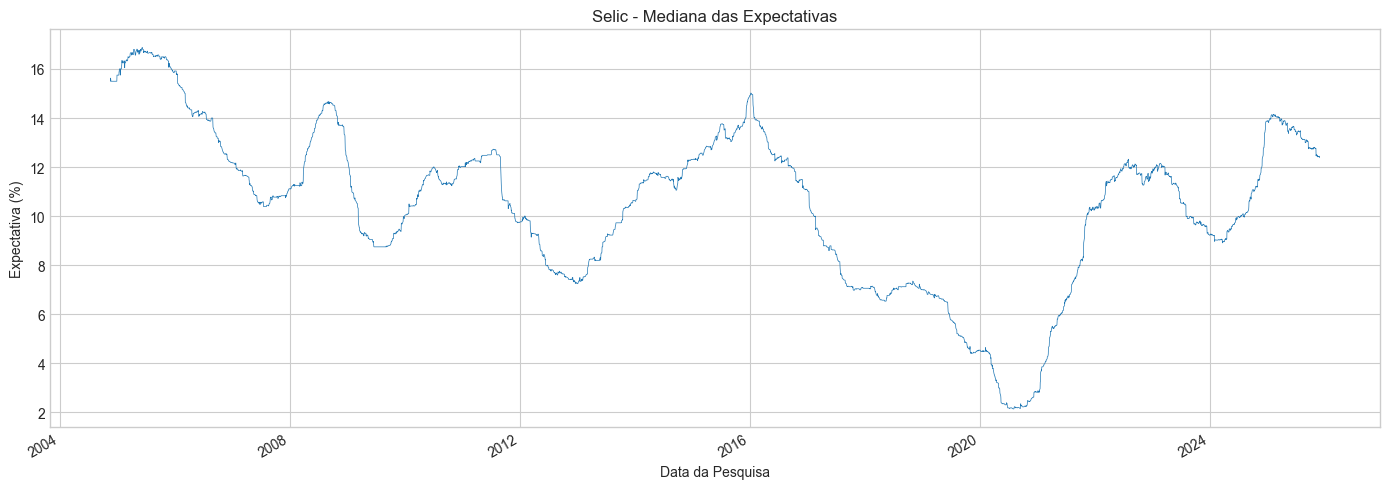

Periodo: 2004-11-18 00:00:00 a 2025-11-28 00:00:00
Registros: 82,070


In [36]:
# Exemplo: Selic - Mediana ao longo do tempo
if 'selic' in df_expectations['_source'].values:
    selic_exp = df_expectations[df_expectations['_source'] == 'selic'].copy()
    
    if 'Mediana' in selic_exp.columns:
        mediana_diaria = selic_exp.groupby(selic_exp.index)['Mediana'].mean()
        
        fig, ax = plt.subplots(figsize=(14, 5))
        mediana_diaria.plot(ax=ax, linewidth=0.5)
        
        ax.set_title('Selic - Mediana das Expectativas')
        ax.set_xlabel('Data da Pesquisa')
        ax.set_ylabel('Expectativa (%)')
        plt.tight_layout()
        plt.show()
        
        print(f"Periodo: {selic_exp.index.min()} a {selic_exp.index.max()}")
        print(f"Registros: {len(selic_exp):,}")

## 8. Resumo

Este notebook verificou a integridade dos dados coletados:

- **SGS Daily**: Series diarias de taxas de juros e cambio
- **SGS Monthly**: Series mensais de atividade economica e inflacao
- **Expectations**: Expectativas de mercado do Relatorio Focus

Para analises mais detalhadas (correlacoes, tendencias, previsoes), crie notebooks especificos.